# Matplotlib In-Class Exercise: City Bike Rentals

A city bike service recorded rental activity and weather conditions over 14 days. Your task is to process the supplied NumPy arrays, choose appropriate visualizations, and explain what the charts reveal.

## Learning goals

By completing the exercise, you will practise how to:

- choose a chart based on a data question
- combine NumPy calculations with Matplotlib
- create line, bar, scatter, and histogram plots
- highlight an important value with an annotation
- combine several views with subplots
- communicate findings in words

Complete the tasks in order. Use `fig, ax = plt.subplots()` rather than only `plt.plot(...)`.

## Dataset

The arrays contain:

- `days`: 14 ordered day labels
- `rentals`: number of bike rentals per day
- `temperature`: average daily temperature in °C
- `rainfall`: daily rainfall in millimetres

Run the setup cell before starting the tasks.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

days = np.array([
    "Mon 1", "Tue 1", "Wed 1", "Thu 1", "Fri 1", "Sat 1", "Sun 1",
    "Mon 2", "Tue 2", "Wed 2", "Thu 2", "Fri 2", "Sat 2", "Sun 2"
])

rentals = np.array([118, 132, 145, 98, 170, 215, 238,
                    126, 151, 165, 109, 188, 232, 260])

temperature = np.array([12, 14, 16, 11, 18, 21, 23,
                        13, 15, 17, 12, 19, 22, 24])

rainfall = np.array([0.0, 0.0, 0.0, 8.2, 0.0, 0.0, 0.0,
                     2.4, 0.0, 0.0, 6.8, 0.0, 0.0, 0.0])

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

In [3]:
print("Number of days:", days.size)
print("Rental range:", rentals.min(), "to", rentals.max())
print("Temperature range:", temperature.min(), "to", temperature.max(), "°C")

Number of days: 14
Rental range: 98 to 260
Temperature range: 11 to 24 °C


## Task 1 — Visualize the Daily Rental Pattern

Create a visualization showing how bike rentals changed across the 14 ordered days.

Requirements:

- choose an appropriate chart type
- use markers so individual days are visible
- add a meaningful title and axis labels with units
- rotate day labels if needed

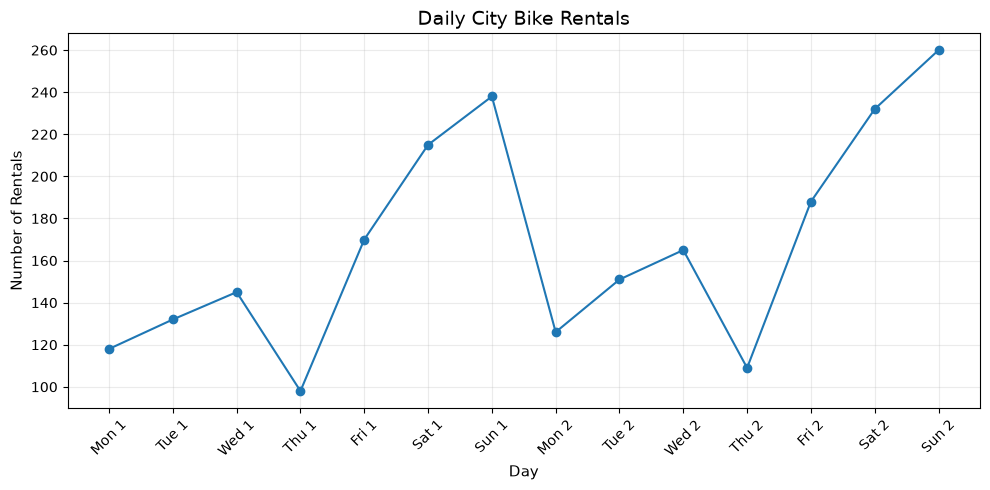

In [14]:
# Write your Task 1 solution here
fig, ax = plt.subplots()
ax.plot(days, rentals, marker='o', linestyle='-', color='tab:blue')
ax.set_title("Daily City Bike Rentals")
ax.set_xlabel("Day")
ax.set_ylabel("Number of Rentals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Task 2 — Compare Week 1 and Week 2

Use NumPy to calculate total rentals for:

- Week 1: the first seven days
- Week 2: the final seven days

Visualize the two totals using an appropriate category-comparison chart. Display the value of each total on or above its mark.

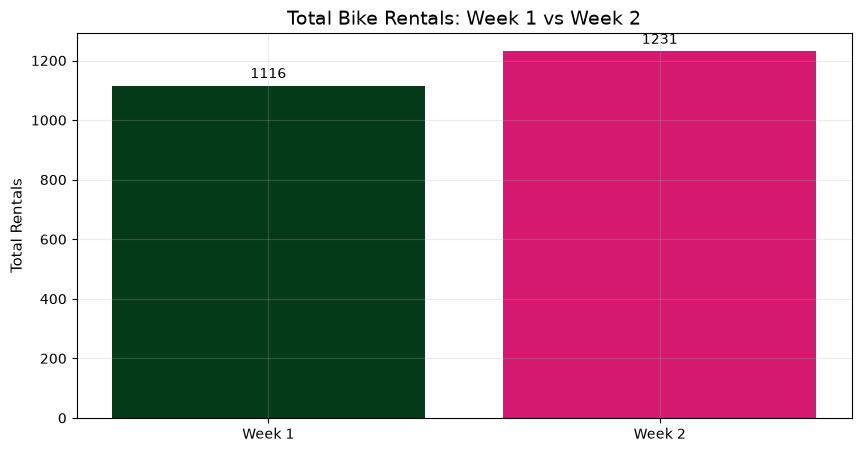

In [20]:
# Write your Task 2 solution here
week1_total = np.sum(rentals[:7])
week2_total = np.sum(rentals[7:])
weeks = ["Week 1", "Week 2"]
totals = [week1_total, week2_total]

fig, ax = plt.subplots()
bars = ax.bar(weeks, totals, color=["#053A18", "#D51971"], )
ax.set_title("Total Bike Rentals: Week 1 vs Week 2")
ax.set_ylabel("Total Rentals")

ax.bar_label(bars, fmt="%.0f", padding=3)

plt.show()

## Task 3 — Investigate Temperature and Rentals

Create a visualization that helps answer:

**Are higher temperatures associated with more bike rentals?**

Requirements:

- put temperature on the x-axis
- put rentals on the y-axis
- add a meaningful title and labels with units
- write one sentence below the chart describing the visible relationship

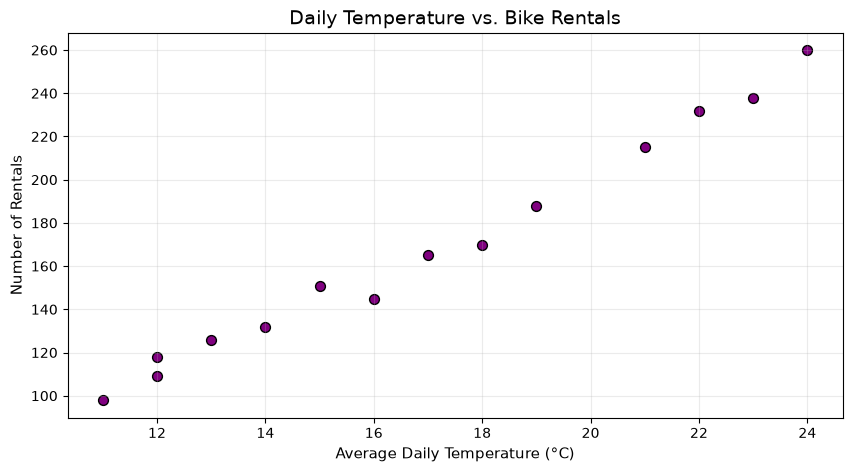

In [21]:
# Write your Task 3 solution here
fig, ax = plt.subplots()
ax.scatter(temperature, rentals, color='purple', edgecolors='black', s=50)
ax.set_title("Daily Temperature vs. Bike Rentals")
ax.set_xlabel("Average Daily Temperature (°C)")
ax.set_ylabel("Number of Rentals")
plt.show()

**Your interpretation:** Replace this text with one sentence.

## Task 4 — Examine the Distribution of Daily Rentals

Visualize how the 14 rental values are distributed.

Requirements:

- use **five bins**
- add a vertical dashed line showing the mean number of rentals
- include a legend identifying the mean
- label both axes clearly

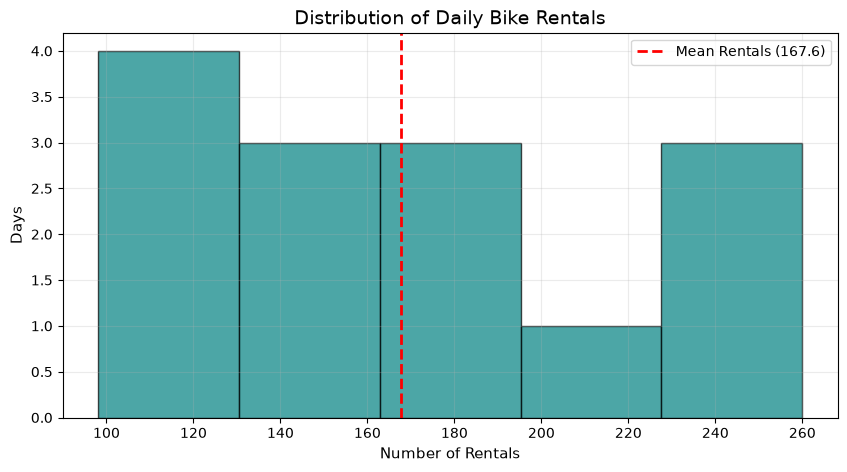

In [22]:
# Write your Task 4 solution here
fig, ax = plt.subplots()
mean_rentals = np.mean(rentals)

ax.hist(rentals, bins=5, color='teal', edgecolor='black', alpha=0.7)
ax.axvline(mean_rentals, color='red', linestyle='--', linewidth=2, label=f'Mean Rentals ({mean_rentals:.1f})')

ax.set_title("Distribution of Daily Bike Rentals")
ax.set_xlabel("Number of Rentals")
ax.set_ylabel("Days")
ax.legend()
plt.show()

## Task 5 — Find and Highlight the Busiest Day

Use NumPy to find:

- the index of the highest rental value
- the name of the corresponding day
- the number of rentals on that day

Recreate the daily rental chart and annotate the busiest point. The annotation should contain both the day and rental count.

Useful functions: `np.argmax()` and `ax.annotate()`.

## Task 6 — Create a Bike-Rental Dashboard

Create one **2 × 2 figure** containing:

1. the daily rental pattern
2. Week 1 and Week 2 totals
3. temperature versus rentals
4. the distribution of daily rentals

Add a main figure title using `fig.suptitle()` and make sure subplot labels do not overlap.

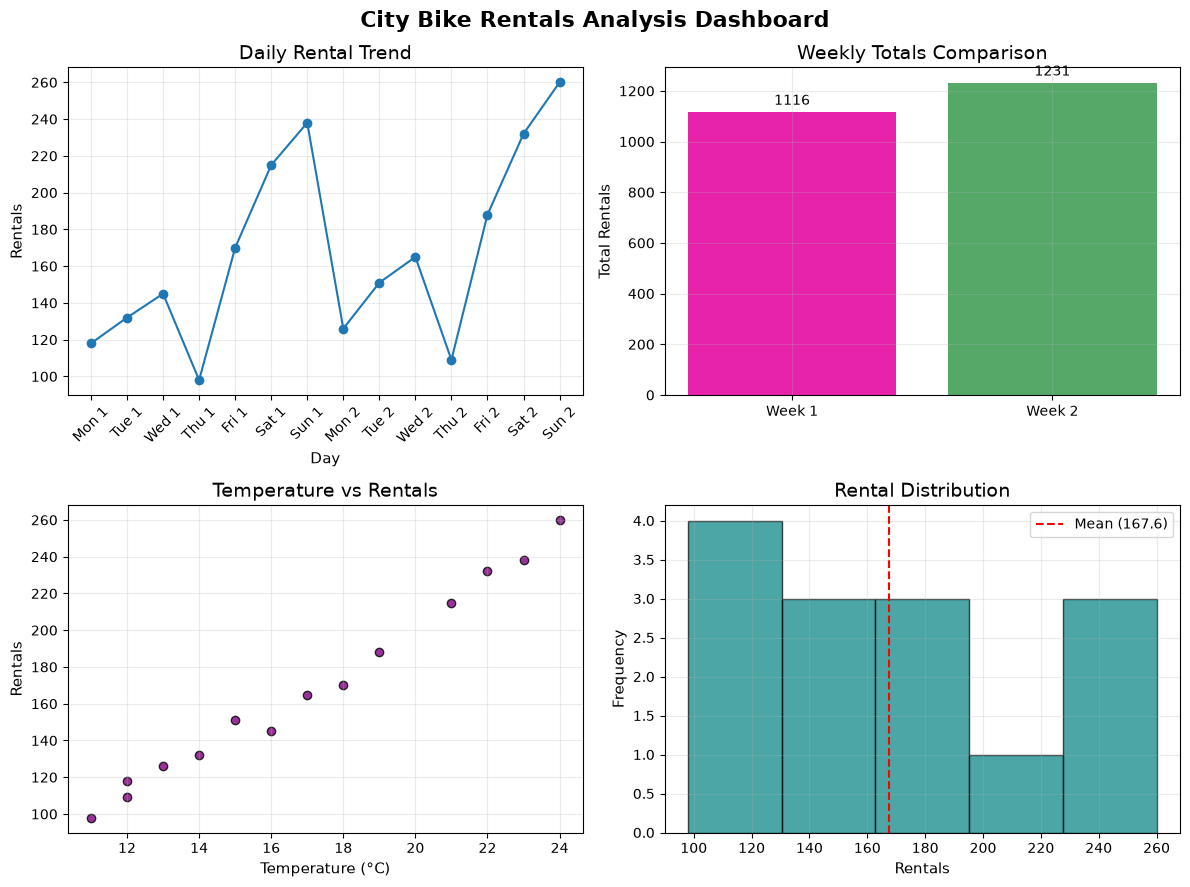

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Prepare dashboard layout
fig, axs = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("City Bike Rentals Analysis Dashboard", fontsize=16, fontweight='bold')

# 1. Daily Rental Trend (Line Chart)
axs[0, 0].plot(days, rentals, marker='o', color='tab:blue')
axs[0, 0].set_title("Daily Rental Trend")
axs[0, 0].set_xlabel("Day")
axs[0, 0].set_ylabel("Rentals")
axs[0, 0].tick_params(axis='x', rotation=45)

# 2. Weekly Totals Comparison (Bar Chart)
axs[0, 1].bar(weeks, totals, color=["#E723AC", '#55A868'])
axs[0, 1].set_title("Weekly Totals Comparison")
axs[0, 1].set_ylabel("Total Rentals")
axs[0, 1].bar_label(axs[0, 1].containers[0], padding=3)

# 3. Temperature vs Rentals (Scatter Plot)
axs[1, 0].scatter(temperature, rentals, color='purple', edgecolors='black', alpha=0.8)
axs[1, 0].set_title("Temperature vs Rentals")
axs[1, 0].set_xlabel("Temperature (°C)")
axs[1, 0].set_ylabel("Rentals")

# 4. Rental Distribution (Histogram)
axs[1, 1].hist(rentals, bins=5, color='teal', edgecolor='black', alpha=0.7)
axs[1, 1].axvline(mean_rentals, color='red', linestyle='--', label=f'Mean ({mean_rentals:.1f})')
axs[1, 1].set_title("Rental Distribution")
axs[1, 1].set_xlabel("Rentals")
axs[1, 1].set_ylabel("Frequency")
axs[1, 1].legend()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

## Final Interpretation

Based on your calculations and visualizations, write **2–3 observations** about the bike-rental data. Each statement should refer to evidence visible in a chart or calculated from the arrays.

1. Replace this text with your first observation.
2. Replace this text with your second observation.
3. Optional third observation.

## Submission Checklist

- [ ] Every chart answers the stated question.
- [ ] Every chart has a meaningful title.
- [ ] Axes are labelled and units are included where appropriate.
- [ ] Week totals and the busiest day were calculated with NumPy.
- [ ] The dashboard contains four readable subplots.
- [ ] The final observations describe the data, not only the code.